# OIBSIP Data Analytics – Task 1
## Exploratory Data Analysis on Retail Sales Data

**Name:** Kalimera Sai Chandu  
**Track:** Data Analytics  
**Internship:** Oasis Infobyte Internship Program

### Project Objective

The objective of this project is to perform exploratory data analysis on retail sales data and identify useful patterns in sales performance and customer characteristics.

### Analysis Objectives

- Understand the structure and quality of the dataset
- Analyze customer demographics
- Examine monthly and quarterly sales trends
- Compare product category performance
- Study relationships between numerical variables
- Identify actionable business insights

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("retail_sales_dataset.csv")

In [ ]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [ ]:
df.shape

(1000, 9)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [ ]:

numeric_columns = ["Age", "Quantity", "Price per Unit", "Total Amount"]

print("Mean:")
print(df[numeric_columns].mean())

print("\nMedian:")
print(df[numeric_columns].median())

print("\nMode:")
print(df[numeric_columns].mode().iloc[0])

print("\nStandard Deviation:")
print(df[numeric_columns].std())

Mean:
Age                41.392
Quantity            2.514
Price per Unit    179.890
Total Amount      456.000
dtype: float64

Median:
Age                42.0
Quantity            3.0
Price per Unit     50.0
Total Amount      135.0
dtype: float64

Mode:
Age               43.0
Quantity           4.0
Price per Unit    50.0
Total Amount      50.0
Name: 0, dtype: float64

Standard Deviation:
Age                13.681430
Quantity            1.132734
Price per Unit    189.681356
Total Amount      559.997632
dtype: float64


In [ ]:
df["Date"] = pd.to_datetime(df["Date"])

In [ ]:
monthly_sales = df.groupby(df["Date"].dt.to_period("M"))["Total Amount"].sum()

monthly_sales

,Total Amount
Date,
2023-01,35450
2023-02,44060
2023-03,28990
2023-04,33870
2023-05,53150
2023-06,36715
2023-07,35465
2023-08,36960
2023-09,23620


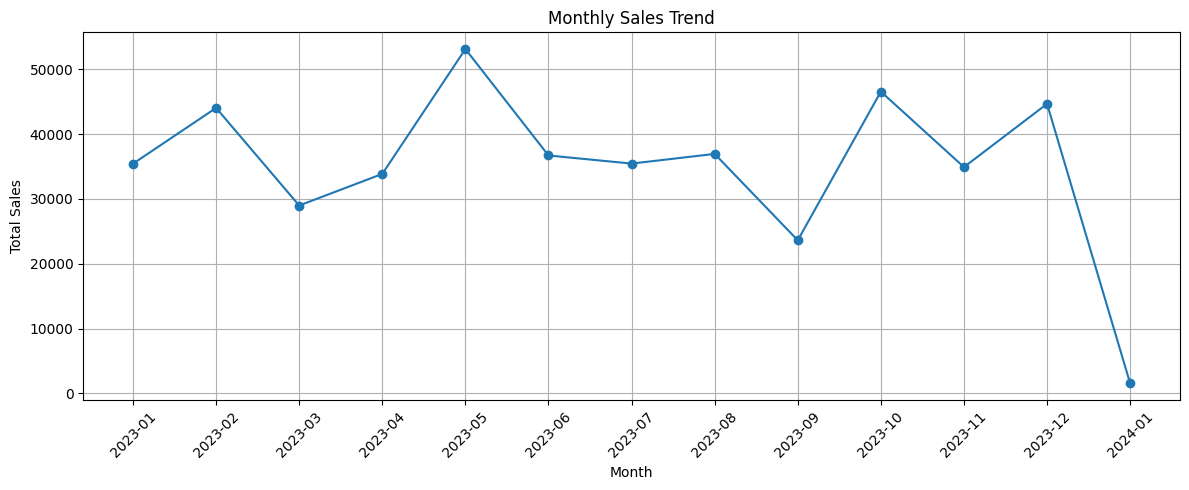

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(monthly_sales.index.astype(str), monthly_sales.values, marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

### Observation

May 2023 recorded the highest monthly sales of 53,150.
September 2023 recorded the lowest monthly sales during 2023, with 23,620.
Overall, monthly sales show noticeable fluctuations throughout the period.

In [ ]:
quarterly_sales = df.groupby(
      df["Date"].dt.to_period("Q")
      )["Total Amount"].sum()
quarterly_sales

,Total Amount
Date,
2023Q1,108500
2023Q2,123735
2023Q3,96045
2023Q4,126190
2024Q1,1530


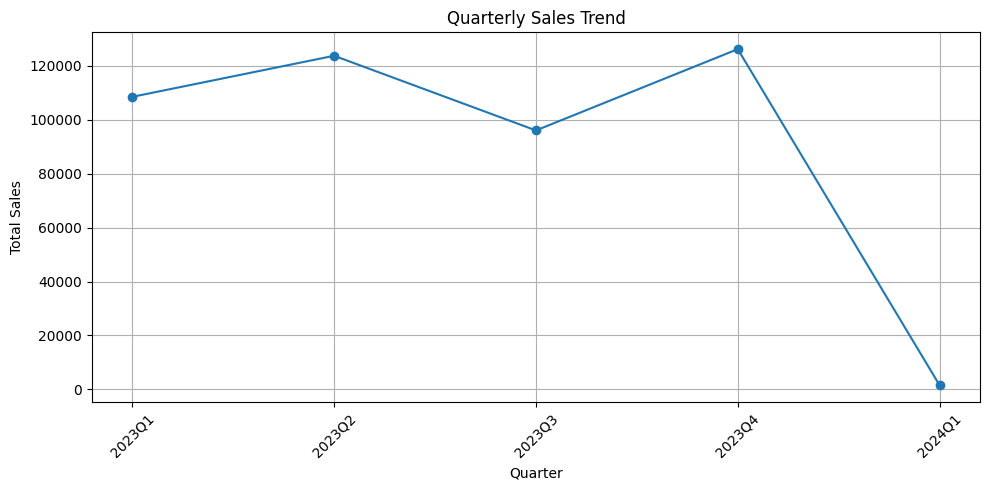

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    quarterly_sales.index.astype(str),
        quarterly_sales.values,
            marker="o"
            )

plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

### Observation

Q4 2023 recorded the highest quarterly sales of 126,190.
Q3 2023 recorded the lowest quarterly sales among the complete quarters, with 96,045.
The Q1 2024 value is only 1,530 because the dataset contains only January 2024 data, so it should not be treated as a complete quarter.

In [ ]:
# Create age groups
df["Age Group"] = pd.cut(
    df["Age"],
    bins=[17, 25, 35, 45, 55, 65],
    labels=["18-25", "26-35", "36-45", "46-55", "56-65"]
)

# Count transactions by age group
age_groups = df["Age Group"].value_counts().sort_index()

age_groups

,count
Age Group,
18-25,169
26-35,205
36-45,202
46-55,229
56-65,195


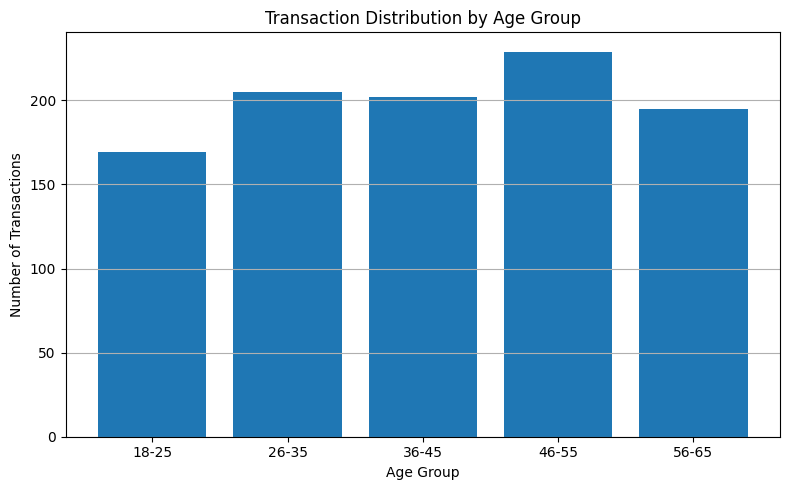

In [ ]:

plt.figure(figsize=(8, 5))
plt.bar(age_groups.index.astype(str), age_groups.values)
plt.title("Transaction Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Transactions")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

### Observation

The 46–55 age group has the highest number of transactions, with 229. The 18–25 age group has the lowest number of transactions, with 169. The transaction distribution is relatively spread across all age groups.

In [ ]:
gender_counts = df["Gender"].value_counts()

gender_counts

,count
Gender,
Female,510
Male,490


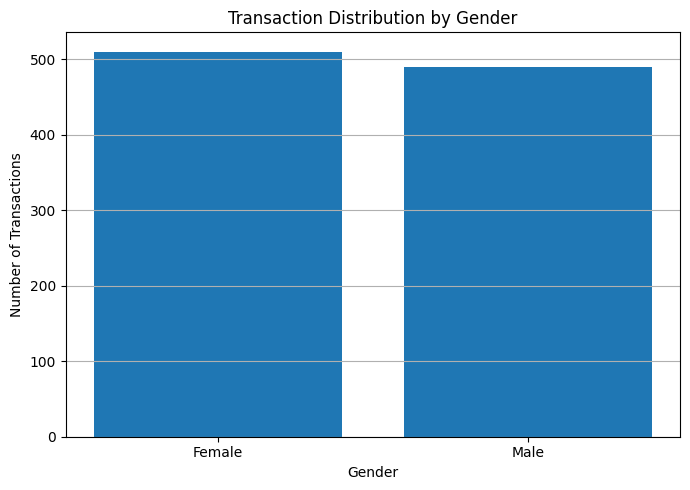

In [ ]:

plt.figure(figsize=(7, 5))
plt.bar(gender_counts.index, gender_counts.values)
plt.title("Transaction Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Transactions")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

### Observation

Female transactions are slightly higher than male transactions, with 510 female transactions compared with 490 male transactions. The distribution is relatively balanced.

In [ ]:
category_sales = df.groupby("Product Category")["Total Amount"].sum().sort_values(ascending=False)

category_sales

,Total Amount
Product Category,
Electronics,156905
Clothing,155580
Beauty,143515


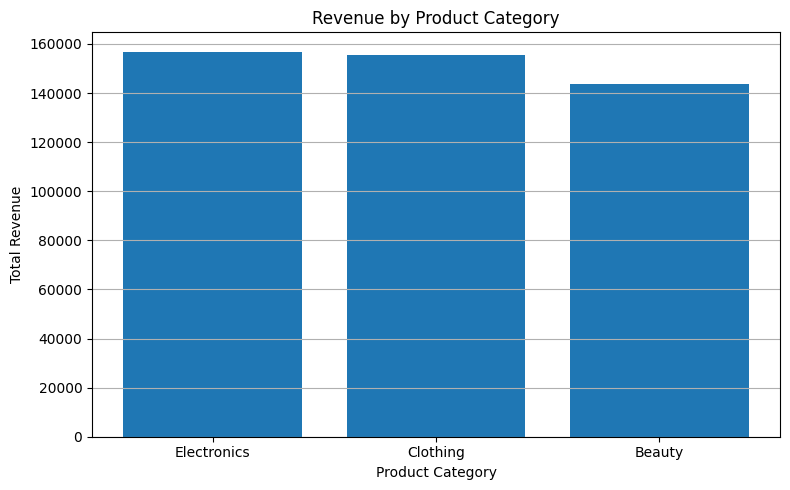

In [ ]:

plt.figure(figsize=(8, 5))
plt.bar(category_sales.index, category_sales.values)
plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

### Observation

Electronics generated the highest total revenue at 156,905, followed closely by Clothing at 155,580. Beauty generated the lowest revenue at 143,515.

In [ ]:
category_quantity = df.groupby("Product Category")["Quantity"].sum().sort_values(ascending=False)

category_quantity

,Quantity
Product Category,
Clothing,894
Electronics,849
Beauty,771


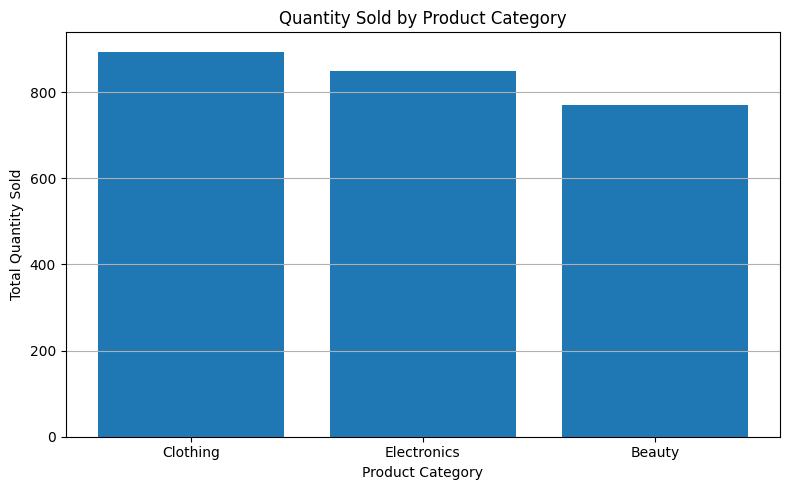

In [ ]:

plt.figure(figsize=(8, 5))
plt.bar(category_quantity.index, category_quantity.values)
plt.title("Quantity Sold by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Quantity Sold")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

### Observation

Clothing had the highest quantity sold with 894 units, followed by Electronics with 849 units and Beauty with 771 units. Although Clothing sold the highest number of units, Electronics generated slightly higher total revenue.

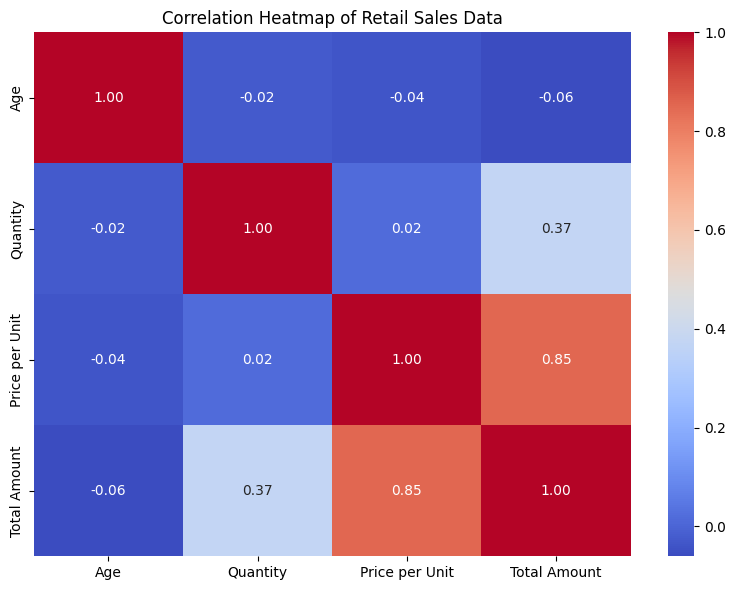

In [ ]:
import seaborn as sns

numeric_columns = [
    "Age",
        "Quantity",
            "Price per Unit",
                "Total Amount"
                ]

correlation = df[numeric_columns].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
                    correlation,
                        annot=True,
                            cmap="coolwarm",
                                fmt=".2f"
                                )

plt.title("Correlation Heatmap of Retail Sales Data")
plt.tight_layout()
plt.show()

### Observation

Price per Unit has a strong positive correlation with Total Amount (0.85), indicating that higher-priced items are generally associated with higher transaction values.

Quantity has a moderate positive correlation with Total Amount (0.37).

Age has a very weak correlation with Total Amount, suggesting that age alone has little linear relationship with transaction value.

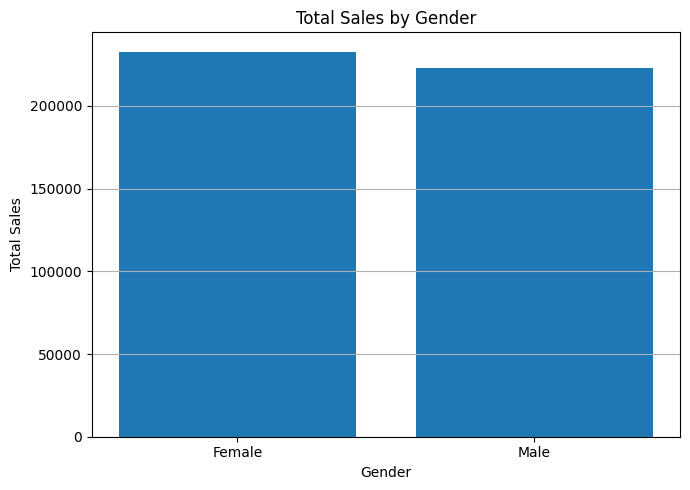

In [ ]:
gender_sales = df.groupby("Gender")["Total Amount"].sum().sort_values(ascending=False)

plt.figure(figsize=(7, 5))

plt.bar(gender_sales.index, gender_sales.values)

plt.title("Total Sales by Gender")
plt.xlabel("Gender")
plt.ylabel("Total Sales")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

### Observation

Female customers generated slightly higher total sales than male customers. This indicates that female customers contributed a slightly larger share of overall sales in the dataset.

Total Sales by Age Group:


,Total Amount
Age Group,
46-55,100690
26-35,98480
36-45,91870
18-25,84550
56-65,80410


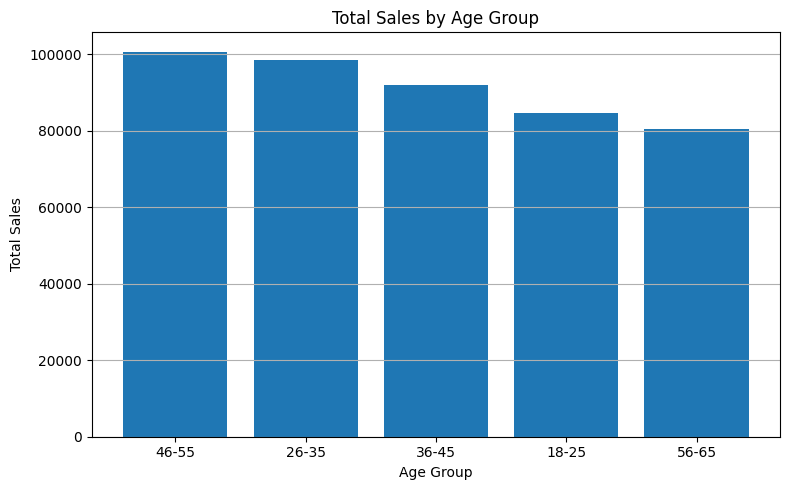

In [ ]:

age_group_sales = df.groupby(
    "Age Group",
    observed=True
)["Total Amount"].sum().sort_values(ascending=False)

print("Total Sales by Age Group:")
display(age_group_sales)

plt.figure(figsize=(8, 5))
plt.bar(
    age_group_sales.index.astype(str),
    age_group_sales.values
)
plt.title("Total Sales by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Total Sales")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

### Observation

The 46–55 age group generated the highest total sales among the age groups, while the 56–65 age group generated the lowest total sales. This suggests that the 46–55 customer segment is an important group for targeted marketing and promotional strategies.

Average Sales per Transaction by Product Category:


,Total Amount
Product Category,
Beauty,467.475570
Electronics,458.786550
Clothing,443.247863


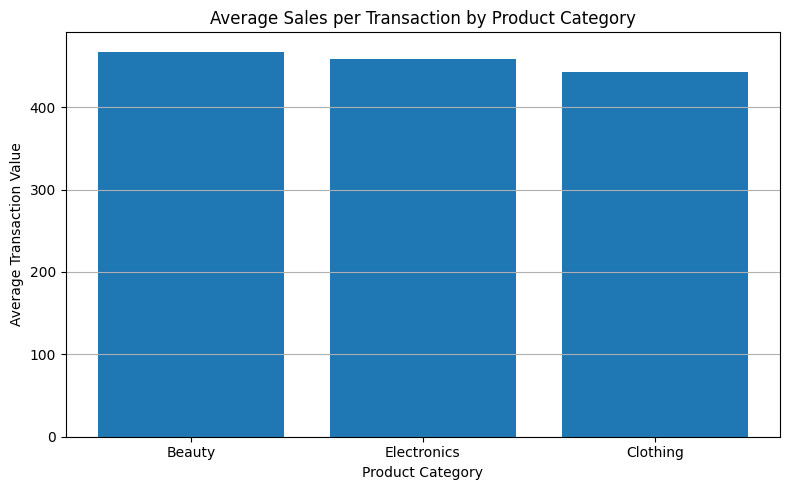

In [ ]:

# Average Sales by Product Category

average_category_sales = df.groupby(
    "Product Category"
)["Total Amount"].mean().sort_values(ascending=False)

print("Average Sales per Transaction by Product Category:")
display(average_category_sales)

plt.figure(figsize=(8, 5))
plt.bar(
    average_category_sales.index,
    average_category_sales.values
)
plt.title("Average Sales per Transaction by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Average Transaction Value")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

### Observation

The average sales per transaction differs across product categories.

- Beauty has the highest average transaction value.
- Electronics has a slightly lower average transaction value than Beauty.
- Clothing has the lowest average transaction value among the three categories.

This suggests that Beauty and Electronics transactions tend to generate higher value per transaction, while Clothing may have an opportunity to increase transaction value through bundles, cross-selling, or promotional offers.

## Data Limitation: Product-Level Analysis

The dataset does not contain an individual Product Name column.

Therefore, a Top 10 best-selling product analysis cannot be performed at the individual product level without introducing unsupported information.

Instead, product performance was analyzed using Product Category, including total revenue, total quantity sold, and average transaction value.

This provides a reliable comparison of the available product categories without creating or assuming product-level data.

In [ ]:

top_10_transactions = df.nlargest(
    10,
    "Total Amount"
)[
    [
        "Transaction ID",
        "Customer ID",
        "Product Category",
        "Quantity",
        "Total Amount"
    ]
]

top_10_transactions

,Transaction ID,Customer ID,Product Category,Quantity,Total Amount
14,15,CUST015,Electronics,4,2000
64,65,CUST065,Electronics,4,2000
71,72,CUST072,Electronics,4,2000
73,74,CUST074,Beauty,4,2000
88,89,CUST089,Electronics,4,2000
92,93,CUST093,Beauty,4,2000
108,109,CUST109,Electronics,4,2000
117,118,CUST118,Electronics,4,2000
123,124,CUST124,Clothing,4,2000
138,139,CUST139,Beauty,4,2000


## Top 10 Highest-Value Transactions

The table above shows the 10 transactions with the highest Total Amount values.

### Observation

The highest-value transactions in the dataset have a Total Amount of 2,000. These transactions represent high-value purchases and include different product categories and quantities. The table provides a useful view of individual transactions that contributed higher amounts to overall sales.

## Final Project Summary

### Key Findings

1. The dataset contains **1,000 retail transactions across 9 columns**, with no missing values or duplicate rows.
2. The **46–55 age group** recorded the highest number of transactions, with **229 transactions**.
3. Female transactions were slightly higher than male transactions, with **510 compared with 490**.
4. **Electronics** generated the highest total revenue at **156,905**.
5. **Clothing** had the highest quantity sold, with **894 units**.
6. **Beauty** had the highest average transaction value among the three product categories.
7. **May 2023** recorded the highest monthly sales at **53,150**.
8. **Q4 2023** recorded the highest sales among the complete quarters at **126,190**.
9. **Price per Unit** had a strong positive correlation with **Total Amount**, with a correlation coefficient of **0.85**.
10. The **46–55 age group** recorded the highest transaction activity and total sales in the dataset.

### Conclusion

The exploratory data analysis provided useful insights into retail sales performance and customer characteristics. The analysis examined data quality, customer demographics, monthly and quarterly sales trends, product category performance, gender-based sales, age-group sales, average transaction values, and relationships between numerical variables.

The results show that **Electronics was the highest-revenue category, while Clothing recorded the highest quantity sold**. The **46–55 age group recorded the highest transaction activity and total sales** in the dataset, and female customers contributed slightly higher sales than male customers. The analysis also identified noticeable variations in monthly and quarterly sales.

The correlation analysis showed a **strong positive relationship between Price per Unit and Total Amount**. Since the dataset does not contain individual product names, product-level Top 10 analysis could not be performed reliably. Therefore, product categories were used for revenue, quantity, and average transaction analysis.

### Business Recommendations

1. **Focus marketing campaigns on the 46–55 customer segment.**
2. **Give additional promotional attention to Electronics** because it generated the highest total revenue.
3. **Use monthly and quarterly sales trends** to improve inventory planning and promotional timing.
4. **Consider bundles, cross-selling, and promotional offers for Clothing** to increase average transaction value.
5. **Continue collecting product-level information**, such as Product Name, to enable more detailed product performance analysis.